# Matplotlib: Formattare i grafici
Matplotlib offre molte opzioni per formattare i grafici, rendendoli più chiari e visivamente accattivanti. Ecco alcune delle principali tecniche di formattazione che puoi utilizzare, ecco una tabella che riassume alcune delle opzioni di formattazione più comuni:
| Opzione di Formattazione | Descrizione |
|-------------------------|-------------|
| `title`                 | Aggiunge un titolo al grafico. |
| `xlabel`                | Aggiunge un'etichetta all'asse x. |
| `ylabel`                | Aggiunge un'etichetta all'asse y. |
| `legend`                | Aggiunge una legenda al grafico. |
| `grid`                  | Aggiunge una griglia al grafico. |
| `xlim` e `ylim`         | Imposta i limiti degli assi x e y. |
| `xticks` e `yticks`     | Imposta i valori e le etichette dei tick sugli assi. |
| `figsize`               | Imposta la dimensione della figura. |
| `color`                 | Imposta il colore delle linee o dei punti. |
| `linestyle`             | Imposta lo stile delle linee (es. solido, tratteggiato). |
| `marker`                | Imposta il tipo di marker per i punti (es. cerchio, quadrato). |
| `fontsize`              | Imposta la dimensione del testo per titoli, etichette e legende. |
| `fontweight`            | Imposta lo spessore del testo (es. normale, grassetto). |
| `alpha`                 | Imposta la trasparenza degli elementi del grafico. |
| `subplot`                | Crea più grafici in una singola figura. |
| `savefig`                | Salva il grafico in un file. |
| `tight_layout`            | Ottimizza la disposizione degli elementi del grafico. |
| `annotate`               | Aggiunge annotazioni al grafico. |
| `text`                   | Aggiunge testo in una posizione specifica del grafico. |
| `colorbar`               | Aggiunge una barra dei colori per rappresentare i valori. |
| `imshow`                  | Visualizza un'immagine o una matrice come grafico. |

## `subplot`
La funzione `subplot` consente di creare più grafici all'interno di una singola figura. La sintassi è `subplot(nrows, ncols, index)`, dove `nrows` è il numero di righe, `ncols` è il numero di colonne e `index` è la posizione del grafico (partendo da 1). 

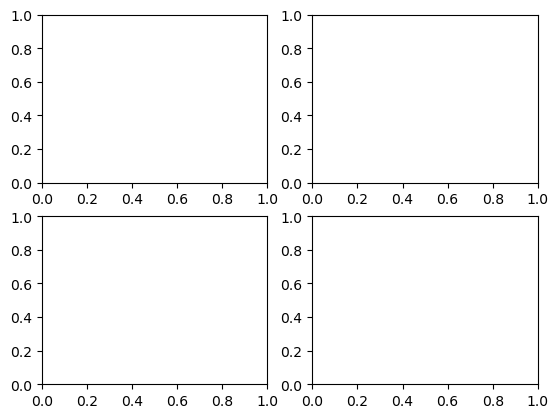

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2)

In [11]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

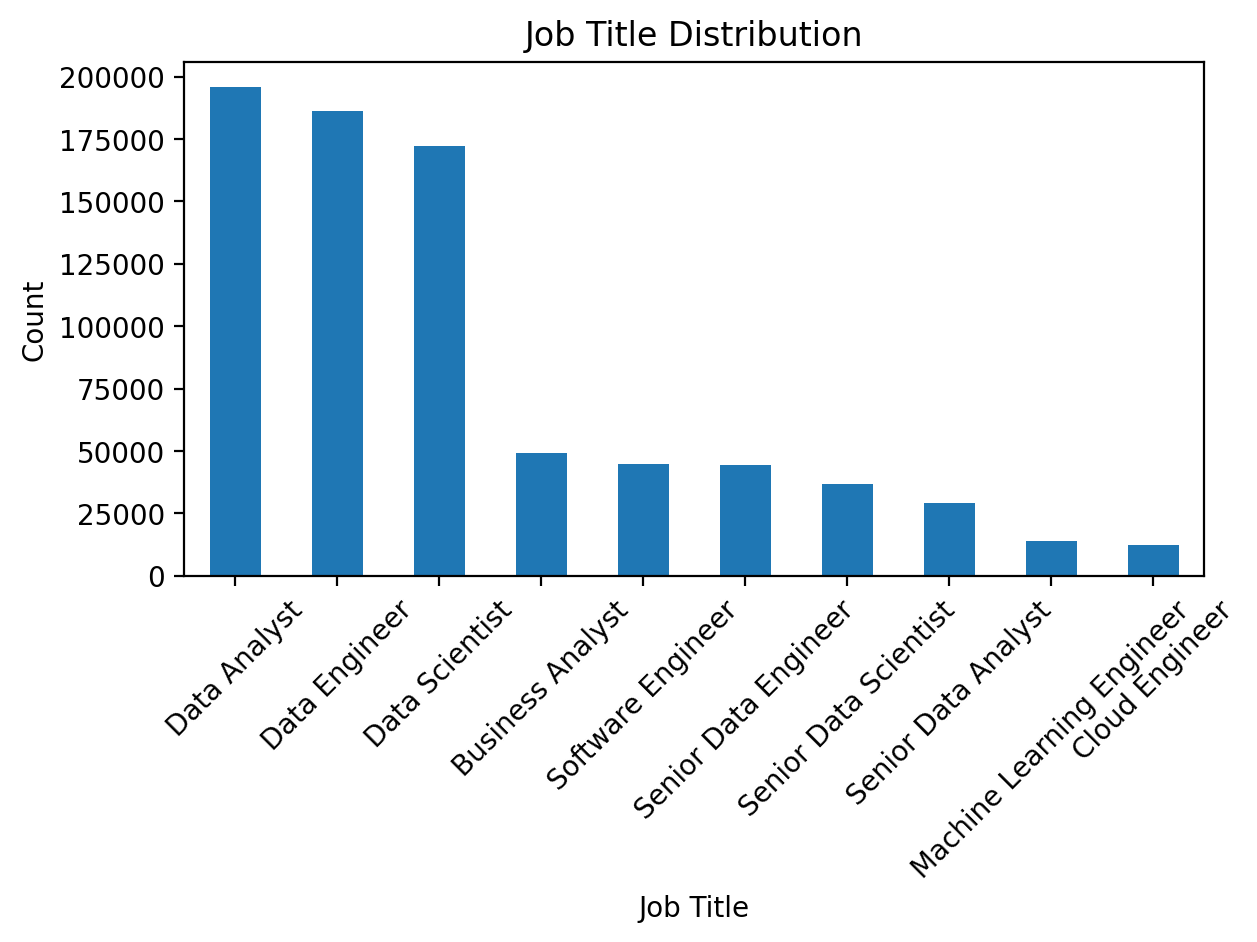

In [16]:
%config InlineBackend.figure_format = 'retina'
df["job_title_short"].value_counts().plot(kind="bar",title="Job Title Distribution")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

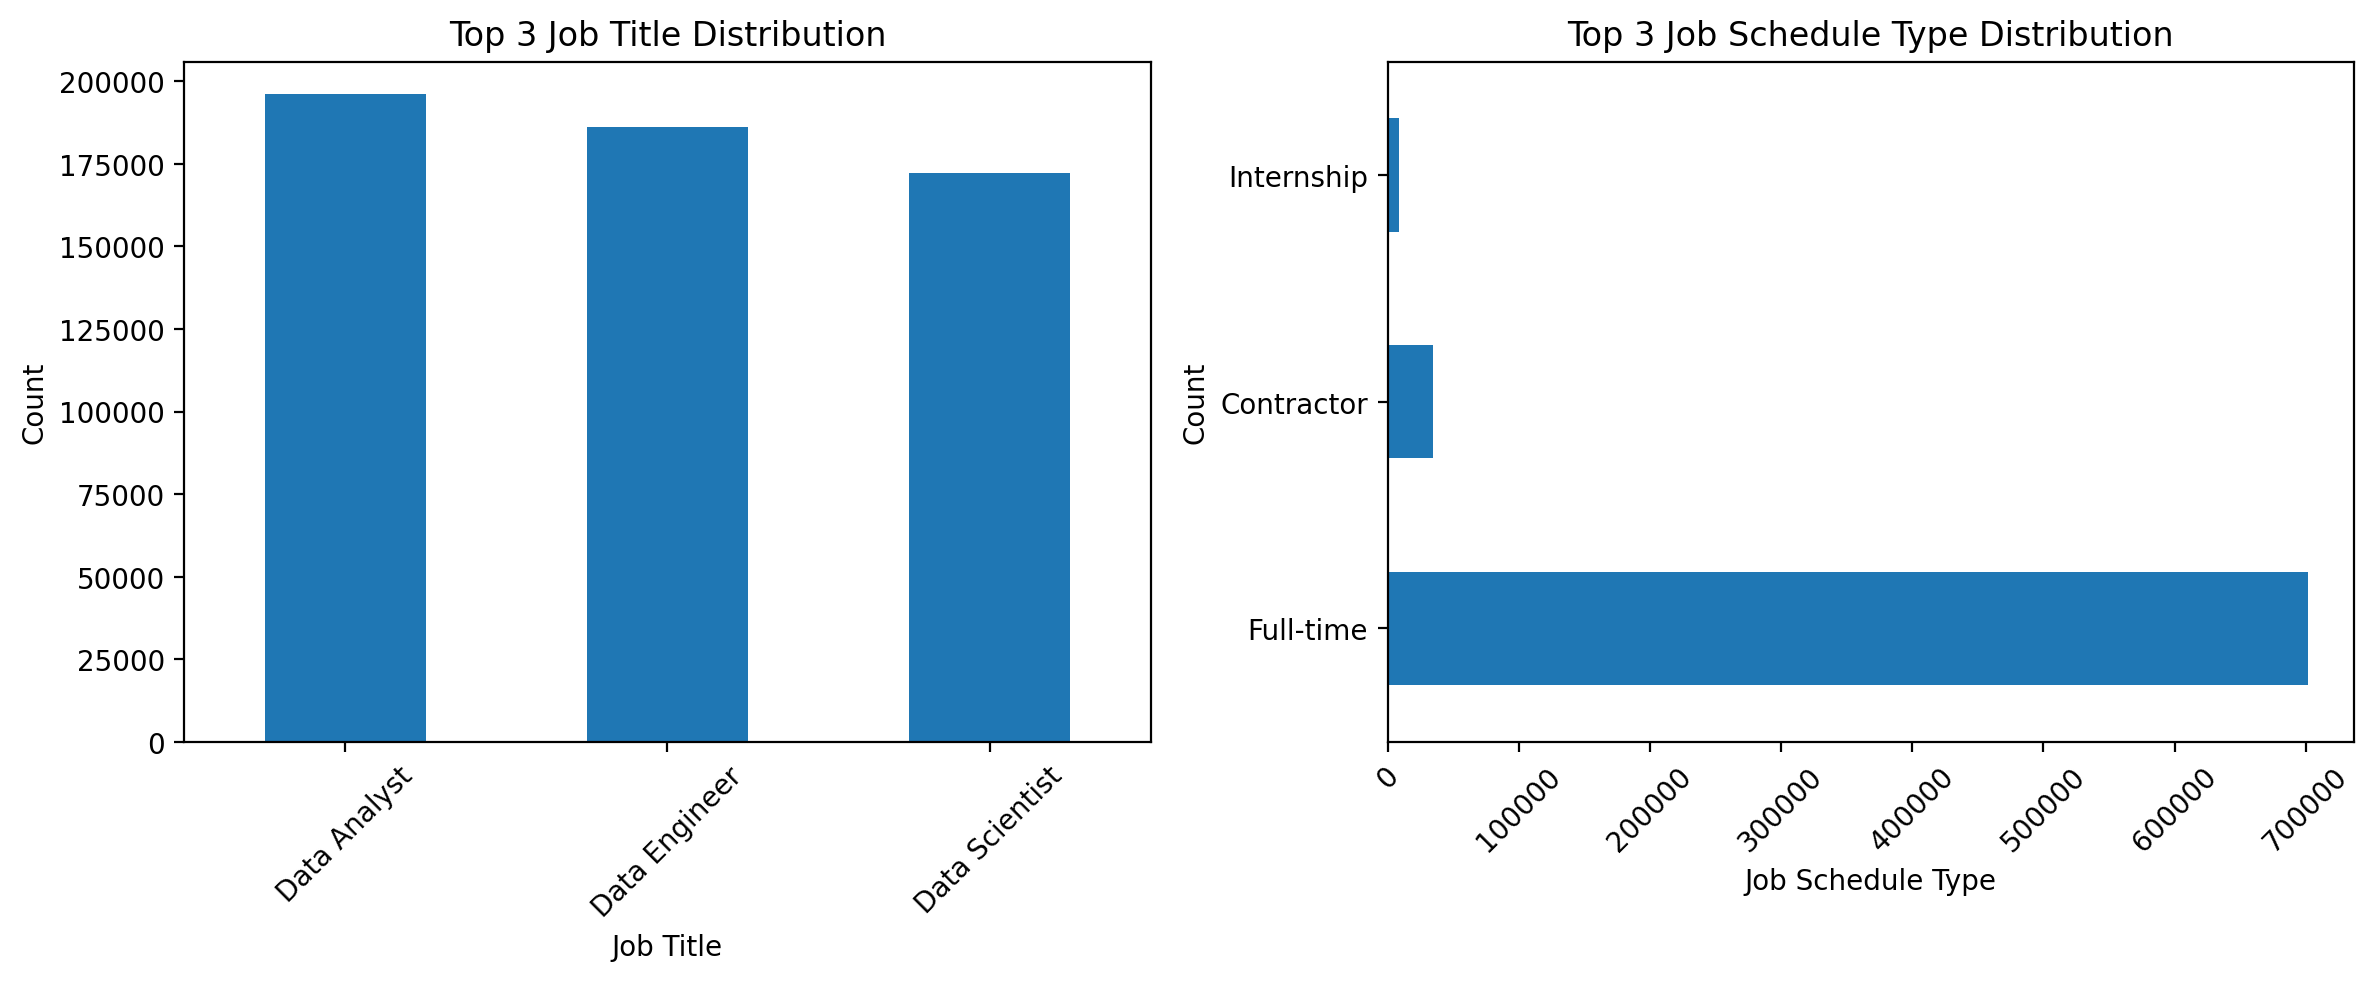

In [29]:
%config InlineBackend.figure_format = 'retina'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['job_title_short'].value_counts().head(3).plot(kind='bar', ax=axes[0], title="Top 3 Job Title Distribution")
axes[0].set_xlabel("Job Title")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)
df['job_schedule_type'].value_counts().head(3).plot(kind='barh', ax=axes[1], title="Top 3 Job Schedule Type Distribution")
axes[1].set_xlabel("Job Schedule Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

Creiamo adesso una figura con 3 grafici per 'Data Analyst', 'Data Engineer' e 'Data Scientist'. Con le top skills per ogni job title.
Usiamo `enumerate` per iterare sui job title e creare un grafico per ognuno di essi. Impostiamo anche `figsize` per rendere i grafici più grandi e leggibili. Infine, usiamo `tight_layout` per ottimizzare la disposizione dei grafici all'interno della figura.

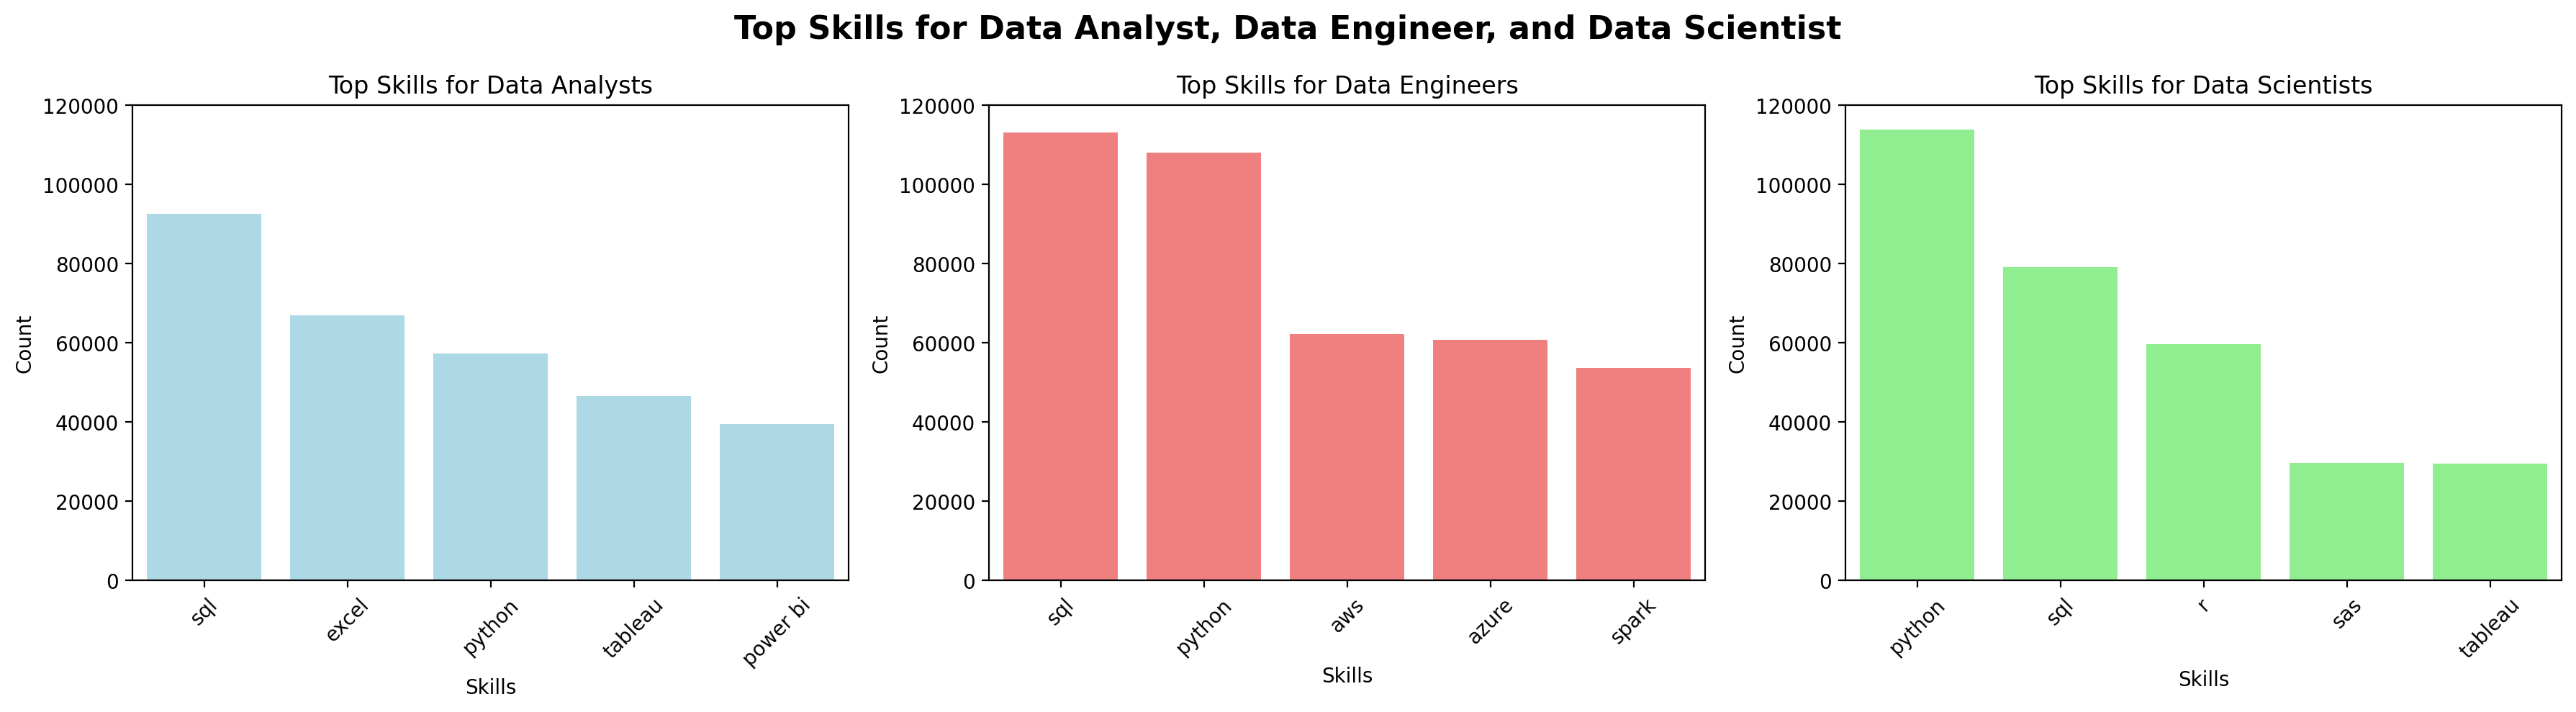

In [59]:
%config InlineBackend.figure_format = 'retina'
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, job_title in enumerate(job_titles):
    top_skills = df[df['job_title_short'] == job_title]['job_skills'].explode().value_counts().head(5)
    top_skills.plot(kind='bar', ax=axes[i], title=f"Top Skills for {job_title}s")
    axes[i].set_xlabel("Skills")
    axes[i].set_ylabel("Count")
    axes[i].set_ylim(0, 120000)
    # colore diverso per ogni grafico
    colors = ['lightblue', 'lightcoral', 'lightgreen']
    axes[i].bar(top_skills.index, top_skills.values, color=colors[i])
    axes[i].tick_params(axis='x', rotation=45)
fig.suptitle("Top Skills for Data Analyst, Data Engineer, and Data Scientist", fontsize=16, fontweight='bold')
plt.tight_layout()

# Matplotlib: Pie Chart
Un pie chart (o grafico a torta) è un tipo di grafico circolare che rappresenta le proporzioni di un insieme di dati. Ogni "fetta" del grafico rappresenta una categoria, e la dimensione di ogni fetta è proporzionale alla quantità che rappresenta. I pie chart sono utili per visualizzare la distribuzione percentuale di un insieme di dati, ma è importante usarli con cautela, poiché possono essere difficili da interpretare quando ci sono molte categorie o quando le differenze tra le categorie sono piccole. Ecco come creare un pie chart con Matplotlib:

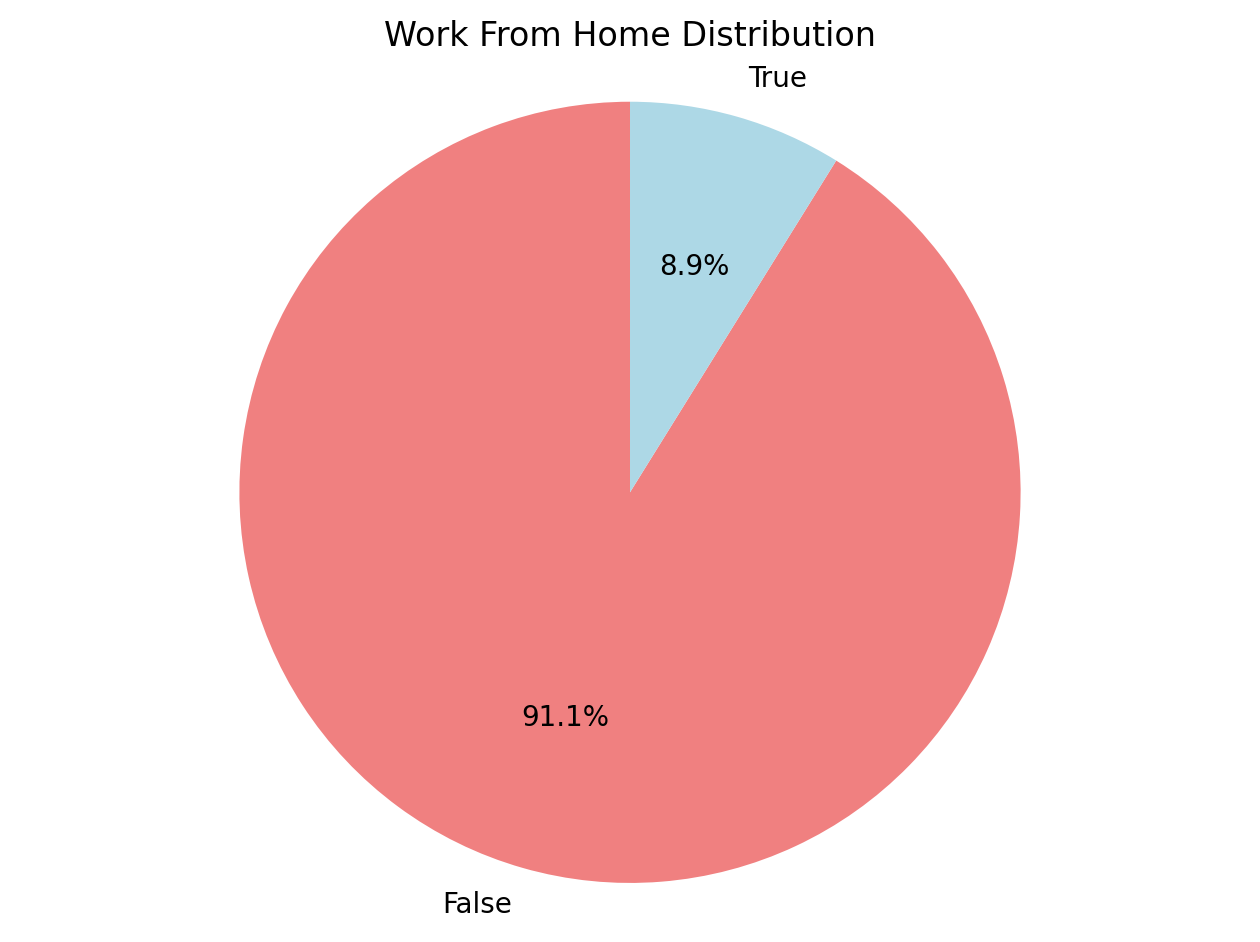

In [67]:
%config InlineBackend.figure_format = 'retina'
df['job_work_from_home'].sample(10) # è un booleano, quindi possiamo usarlo per creare un pie chart

df['job_work_from_home'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, title="Work From Home Distribution", colors=['lightcoral', 'lightblue'])
plt.ylabel("") # rimuove l'etichetta dell'asse y
plt.axis('equal') # assicura che il pie chart sia un cerchio
plt.tight_layout()

Adesso affianchiamo 3 grafici a torta: `job_work_from_home`, `job_no_degree_mention` e `job_health_insurance`. Questi grafici mostrano la distribuzione di lavoro da casa, menzione di laurea e assicurazione sanitaria nei job title del dataset. Utilizziamo `subplot` per affiancare i grafici e `tight_layout` per ottimizzare la disposizione.

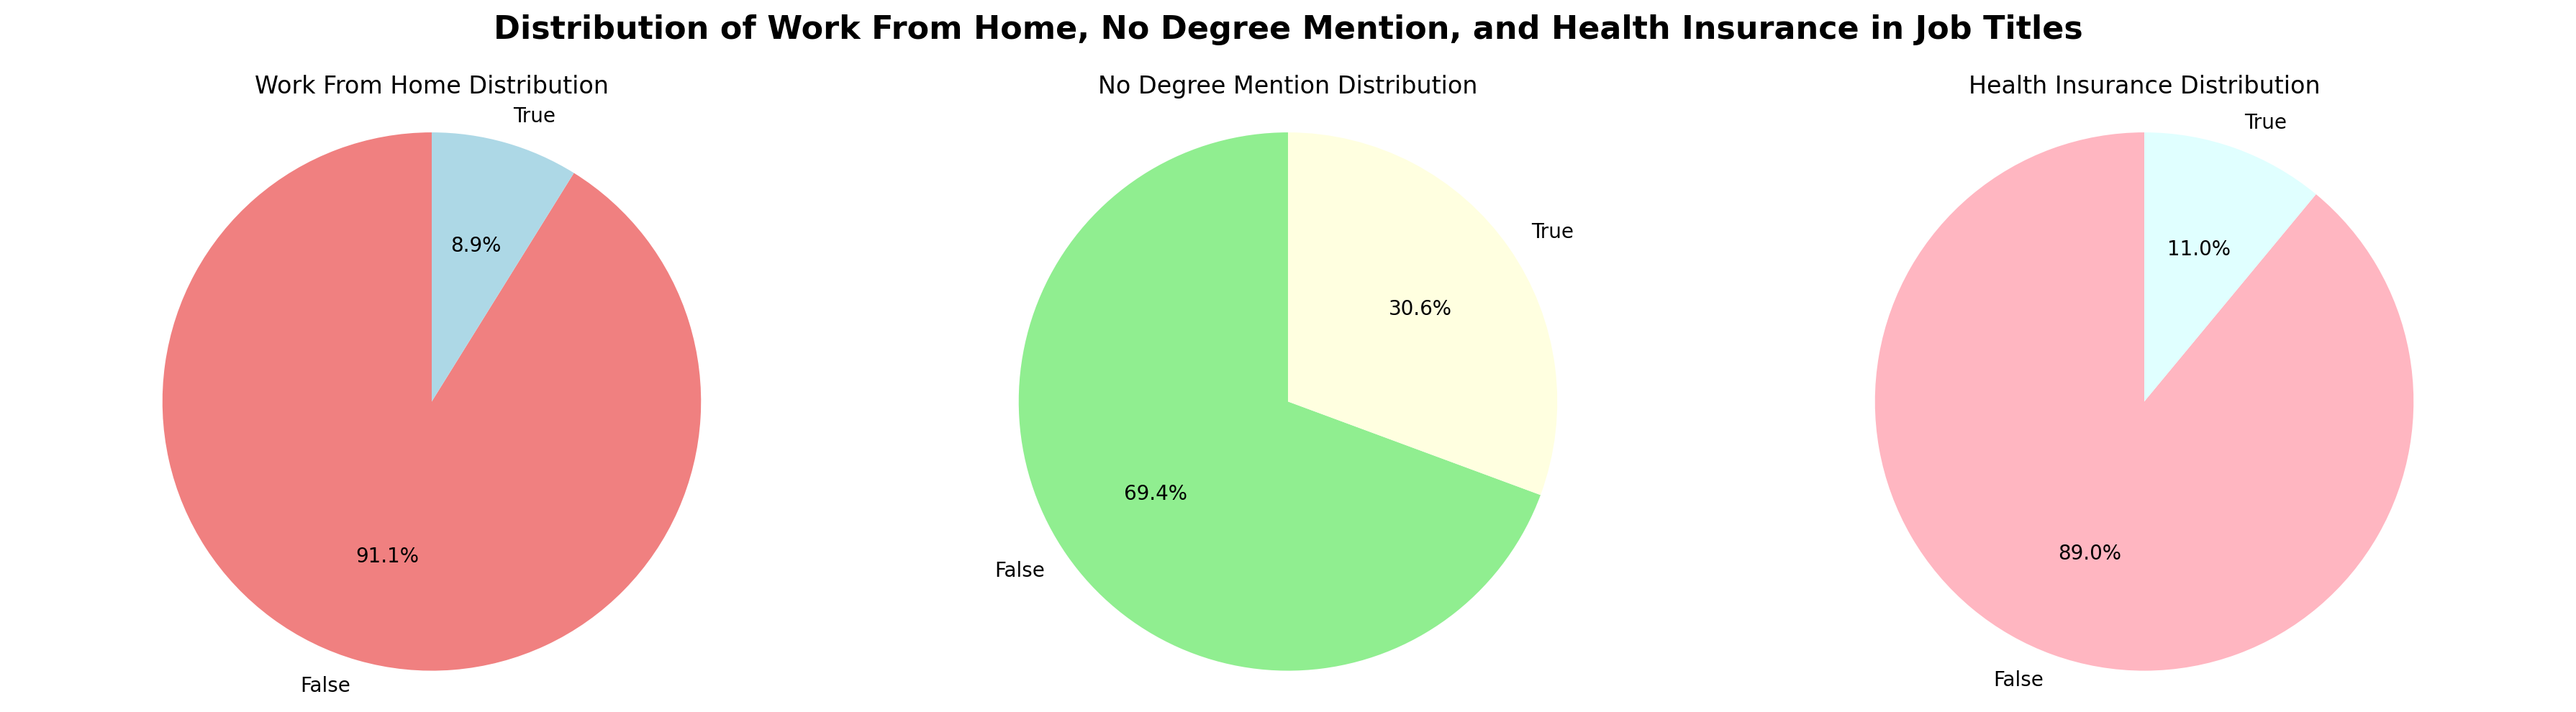

In [73]:
%config InlineBackend.figure_format = 'retina'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dict_columns = {
    'job_work_from_home': "Work From Home Distribution",
    'job_no_degree_mention': "No Degree Mention Distribution",
    'job_health_insurance': "Health Insurance Distribution"
}
colors_list = [['lightcoral', 'lightblue'], ['lightgreen', 'lightyellow'], ['lightpink', 'lightcyan']]
for i, (col, title) in enumerate(dict_columns.items()):
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, title=title, ax=axes[i], colors=colors_list[i])
    axes[i].set_ylabel("")
    axes[i].axis('equal')
fig.suptitle("Distribution of Work From Home, No Degree Mention, and Health Insurance in Job Titles", fontsize=16, fontweight='bold')
plt.tight_layout()

# Matplotlib: Scatter Plot
Un scatter plot (o grafico a dispersione) è un tipo di grafico che utilizza punti per rappresentare la relazione tra due variabili. Ogni punto nel grafico rappresenta un'osservazione, con la posizione del punto determinata dai valori delle due variabili. I scatter plot sono utili per identificare correlazioni, tendenze e outlier nei dati. Ecco come creare un scatter plot con Matplotlib:

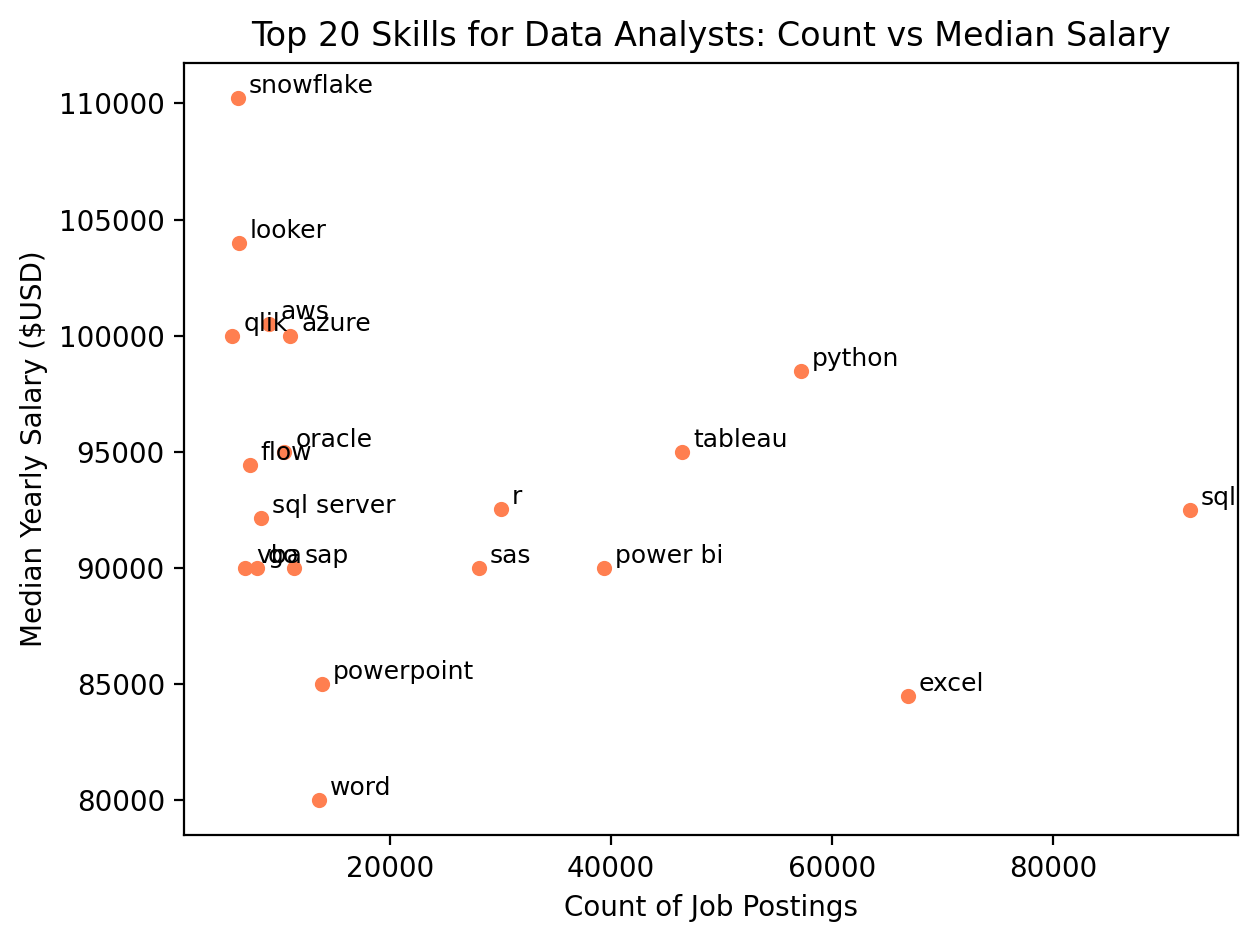

In [134]:
df_DA = df[df['job_title_short'] == 'Data Analyst']
df_DA_exploded = df_DA.explode('job_skills')

skills_stats = df_DA_exploded.groupby('job_skills').agg(
    skills_count = ('job_skills','count'),
    median_salary = ('salary_year_avg', 'median')
)

skills_stats = skills_stats.sort_values(by='skills_count', ascending=False).head(20)

skills_stats.plot(kind='scatter', x='skills_count', y='median_salary', title="Top 20 Skills for Data Analysts: Count vs Median Salary", color='coral')
plt.xlabel("Count of Job Postings")
plt.ylabel("Median Yearly Salary ($USD)")
# aggiungiamo le etichette ai punti
for i, skill in enumerate(skills_stats.index):
    plt.text(skills_stats.iloc[i]['skills_count']+1000, skills_stats.iloc[i]['median_salary'], skill, fontsize=9, ha='left', va='bottom')
    # per aumentare la leggibilità, possiamo spostare leggermente le etichette
plt.tight_layout()


# Matplotlib: Customizzazione Avanzata

Nel `df.plot()` ci sono molte opzioni che possiamo utilizzare per personalizzare i nostri grafici. Ad esempio, possiamo modificare il colore delle linee, lo stile, i marker, la dimensione del testo e molto altro. Vediamo come possiamo migliorare ulteriormente i nostri grafici con alcune tecniche di customizzazione avanzata, come l'aggiunta di annotazioni, la personalizzazione dei colori e l'uso di stili predefiniti. Queste tecniche ci permetteranno di rendere i nostri grafici più informativi e visivamente accattivanti.

| Opzione di Formattazione | Descrizione |
|-------------------------|-------------|
| `linewidth`             | Imposta lo spessore delle linee. |
| `color`                 | Imposta il colore delle linee o dei punti. |
| `colormap`              | Applica una mappa di colori ai dati. |
| `linestyle`             | Imposta lo stile delle linee (es. solido, tratteggiato). |
| `marker`                | Imposta il tipo di marker per i punti (es. cerchio, quadrato). |
| `fontsize`              | Imposta la dimensione del testo per titoli, etichette e legende. |
| `fontweight`            | Imposta lo spessore del testo (es. normale, grassetto). |
| `alpha`                 | Imposta la trasparenza degli elementi del grafico. |
| `style`                 | Applica uno stile predefinito a tutti gli elementi del grafico (es. 'ggplot', 'seaborn'). |
| `annotate`               | Aggiunge annotazioni al grafico. |
| `text`                   | Aggiunge testo in una posizione specifica del grafico. |
| `colorbar`               | Aggiunge una barra dei colori per rappresentare i valori. |
| `imshow`                  | Visualizza un'immagine o una matrice come grafico. |

In [135]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Filtriamo i dati per Data Analyst
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

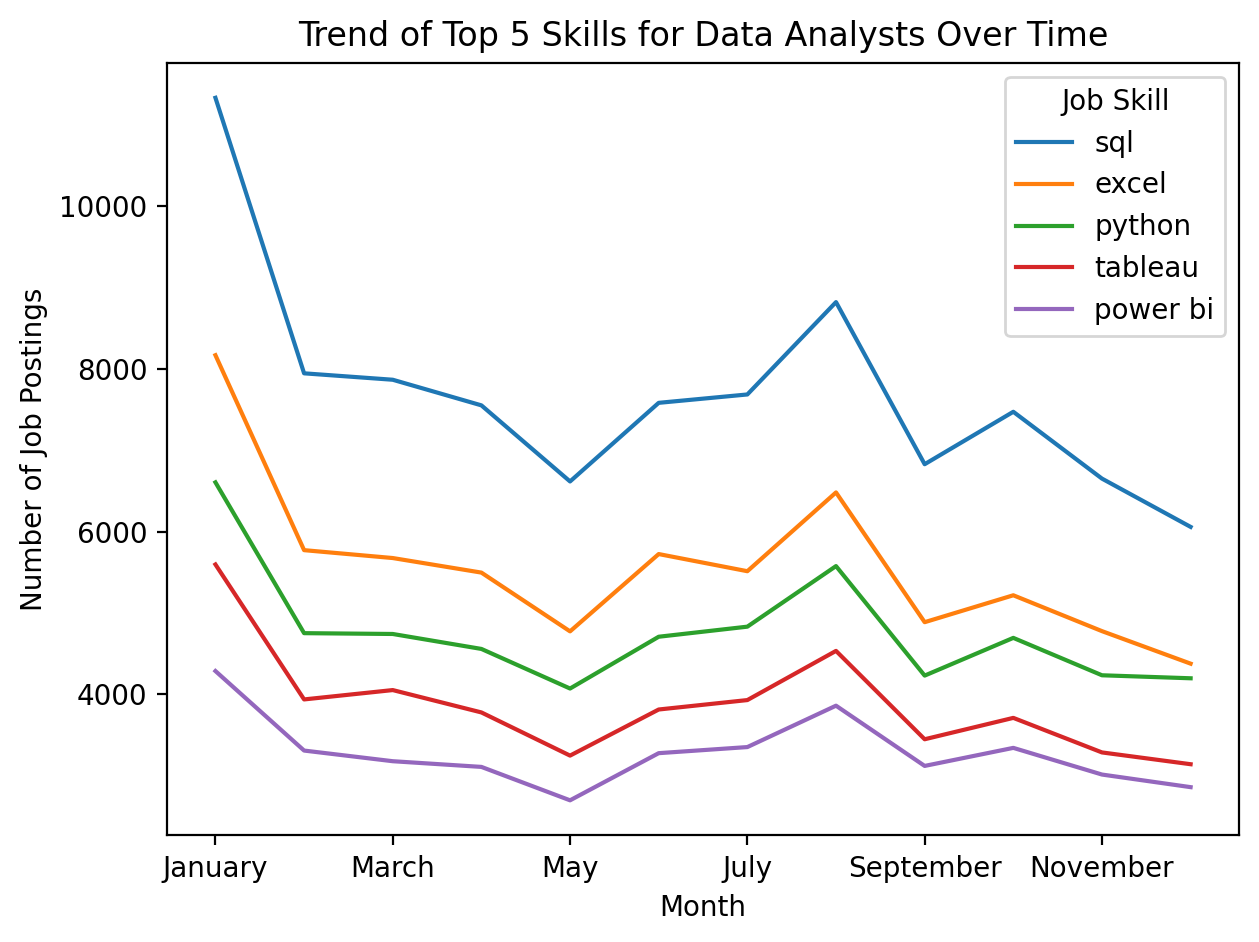

In [138]:
# Creiamo un nuovo DataFrame che contiene solo le offerte di lavoro per Data Analyst e la colonna del mese in cui sono state pubblicate
months_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
# Creiamo una colonna per il mese in cui sono state pubblicate le offerte di lavoro
df_DA["job_posted_month"] = df_DA["job_posted_date"].dt.strftime("%B")

# Esplodiamo la colonna delle competenze per avere una riga per ogni competenza richiesta in ogni offerta di lavoro
df_DA_explode = df_DA.explode("job_skills")

# Identifichiamo le 5 competenze più richieste per i Data Analyst e creiamo un grafico a linee che mostra il trend di queste competenze nel tempo.
top_5_skills = df_DA_explode["job_skills"].value_counts().head(5).index

# Creiamo un DataFrame pivot che mostra il numero di offerte di lavoro per ogni competenza richiesta per i Data Analyst in ogni mese, e poi creiamo un grafico a linee per visualizzare il trend di queste competenze nel tempo.
df_DA_pivot = (
    df_DA_explode[df_DA_explode["job_skills"].isin(top_5_skills)]
    .groupby(["job_posted_month", "job_skills"])
    .size()
    .unstack(fill_value=0)
    .reindex(months_order)
)

# Ordina la legenda in base al picco massimo di ciascuna skill
column_order = df_DA_pivot.max().sort_values(ascending=False).index
df_DA_pivot = df_DA_pivot[column_order]

df_DA_pivot.iloc[:, :5].plot(kind="line", title="Trend of Top 5 Skills for Data Analysts Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Job Skill")
plt.tight_layout()


Vediamo come possiamo migliorare ulteriormente i nostri grafici con alcune tecniche di customizzazione avanzata, come l'aggiunta di annotazioni, la personalizzazione dei colori e l'uso di stili predefiniti. Queste tecniche ci permetteranno di rendere i nostri grafici più informativi e visivamente accattivanti.

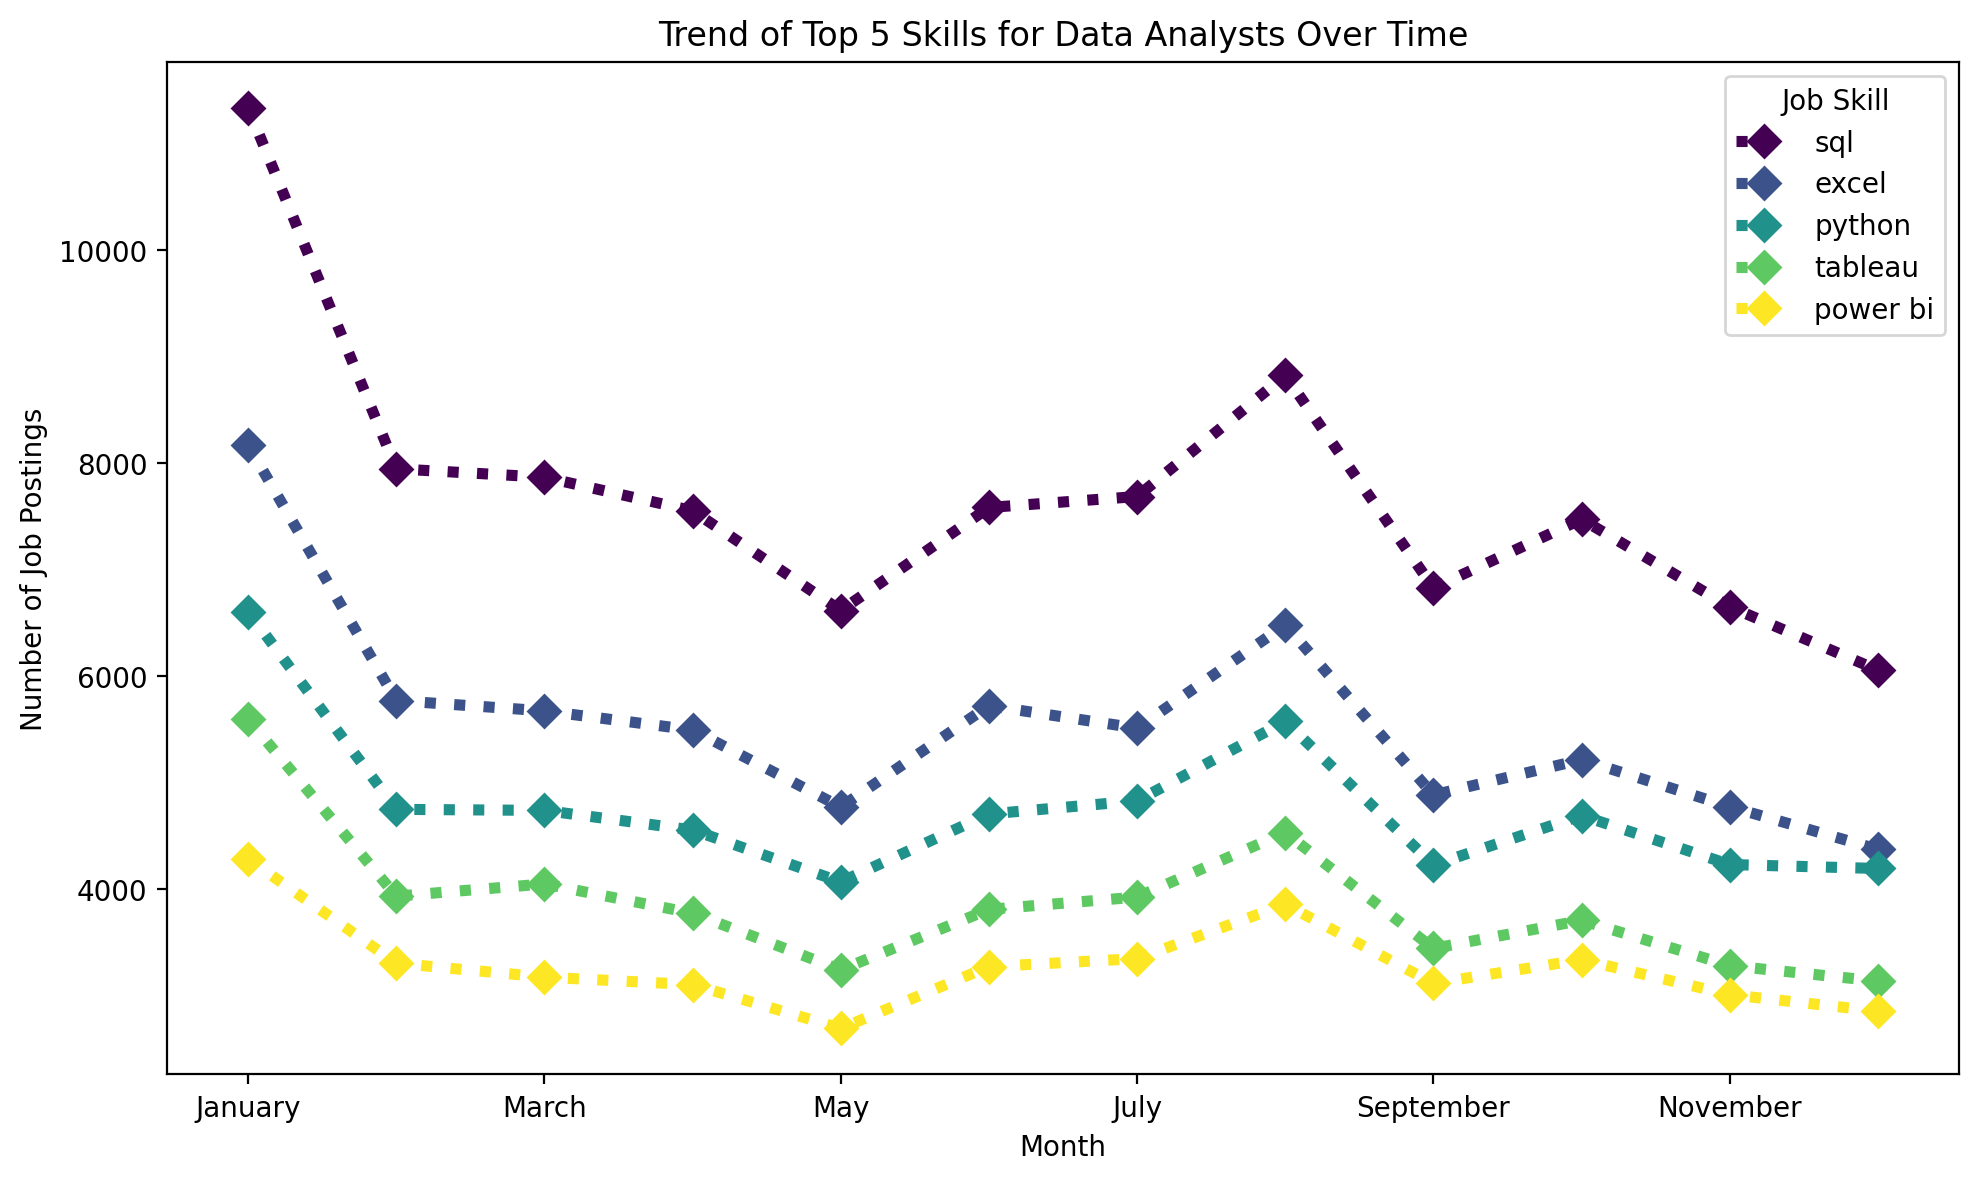

In [153]:
%config InlineBackend.figure_format = 'retina'
df_DA_pivot.iloc[:, :5].plot(
    kind="line", 
    title="Trend of Top 5 Skills for Data Analysts Over Time",
    linewidth=4, # aumenta lo spessore delle linee
    linestyle=':', # rende le linee tratteggiate, altre opzioni includono '--' per linee tratteggiate, '-.' per linee punto-tratteggiate, e '-' per linee continue
    colormap='viridis', # utilizza una mappa di colori predefinita per differenziare le linee, altre opzioni includono 'plasma', 'inferno', 'magma', e 'cividis',
    marker='D', # aggiunge un marker a ogni punto dati, altre opzioni includono 's' per quadrati, '^' per triangoli, 'D' per diamanti, e 'x' per croci
    markersize=8, # aumenta la dimensione dei marker,
    figsize=(10, 6)
)
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Job Skill")
plt.tight_layout()

Adesso miglioriamo lo scatter plot che abbiamo creato in precedenza, aggiungendo alcune annotazioni per evidenziare i punti più interessanti, personalizzando i colori e applicando uno stile predefinito per rendere il grafico più accattivante.

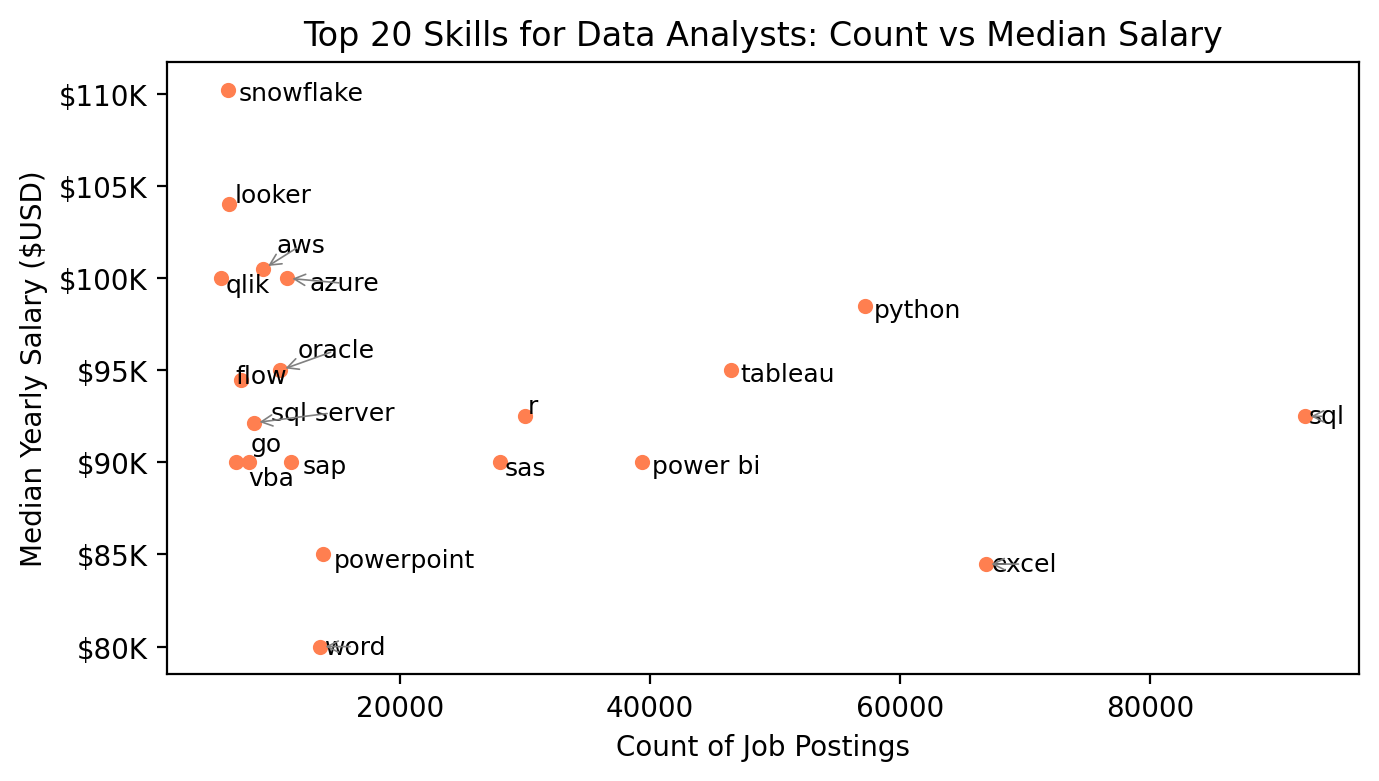

In [210]:
%config InlineBackend.figure_format = 'retina'
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

skills_num = 20

df_DA_exploded = df_DA.explode('job_skills')

skills_stats = df_DA_exploded.groupby('job_skills').agg(
    skills_count = ('job_skills','count'),
    median_salary = ('salary_year_avg', 'median')
)

skills_stats = skills_stats.sort_values(by='skills_count', ascending=False).head(skills_num)

ax = skills_stats.plot(
    kind='scatter', 
    x='skills_count', 
    y='median_salary', 
    title=f"Top {skills_num} Skills for Data Analysts: Count vs Median Salary", 
    color='coral',
    figsize=(7, 4)
)
ax.set_xlabel("Count of Job Postings")
ax.set_ylabel("Median Yearly Salary ($USD)")

# Formattatore: mostra $110K invece di 110000
def thousands(x, pos):
    try:
        x = float(x)
    except Exception:
        return x
    if abs(x) >= 1000:
        return f'${int(x/1000)}K'
    return f'${int(x)}'

ax.yaxis.set_major_formatter(FuncFormatter(thousands))

# Creiamo le etichette come oggetti Text e usiamo adjust_text con parametri più aggressivi
texts = []
for i, skill in enumerate(skills_stats.index):
    x = skills_stats.iloc[i]['skills_count']
    y = skills_stats.iloc[i]['median_salary']
    texts.append(ax.text(x, y, skill, fontsize=9, ha='left', va='center'))

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.6),
    only_move={'points':'y', 'texts':'y'},
    precision=1
)

plt.tight_layout()


# Matplotlib: Histogram
Un istogramma è un tipo di grafico che rappresenta la distribuzione di un insieme di dati. L'asse x rappresenta i valori dei dati, suddivisi in intervalli (o "bin"), mentre l'asse y rappresenta la frequenza o il numero di osservazioni che rientrano in ciascun intervallo. Gli istogrammi sono utili per visualizzare la forma della distribuzione dei dati, identificare eventuali asimmetrie, picchi o outlier. Ecco come creare un istogramma con Matplotlib:

In [190]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

Prendiamo solo i dati di `Data Analyst` negli Stati Uniti e creiamo un istogramma per visualizzare la distribuzione dei job salary. Utilizziamo `hist` per creare l'istogramma e personalizziamo i colori e le etichette per rendere il grafico più chiaro.

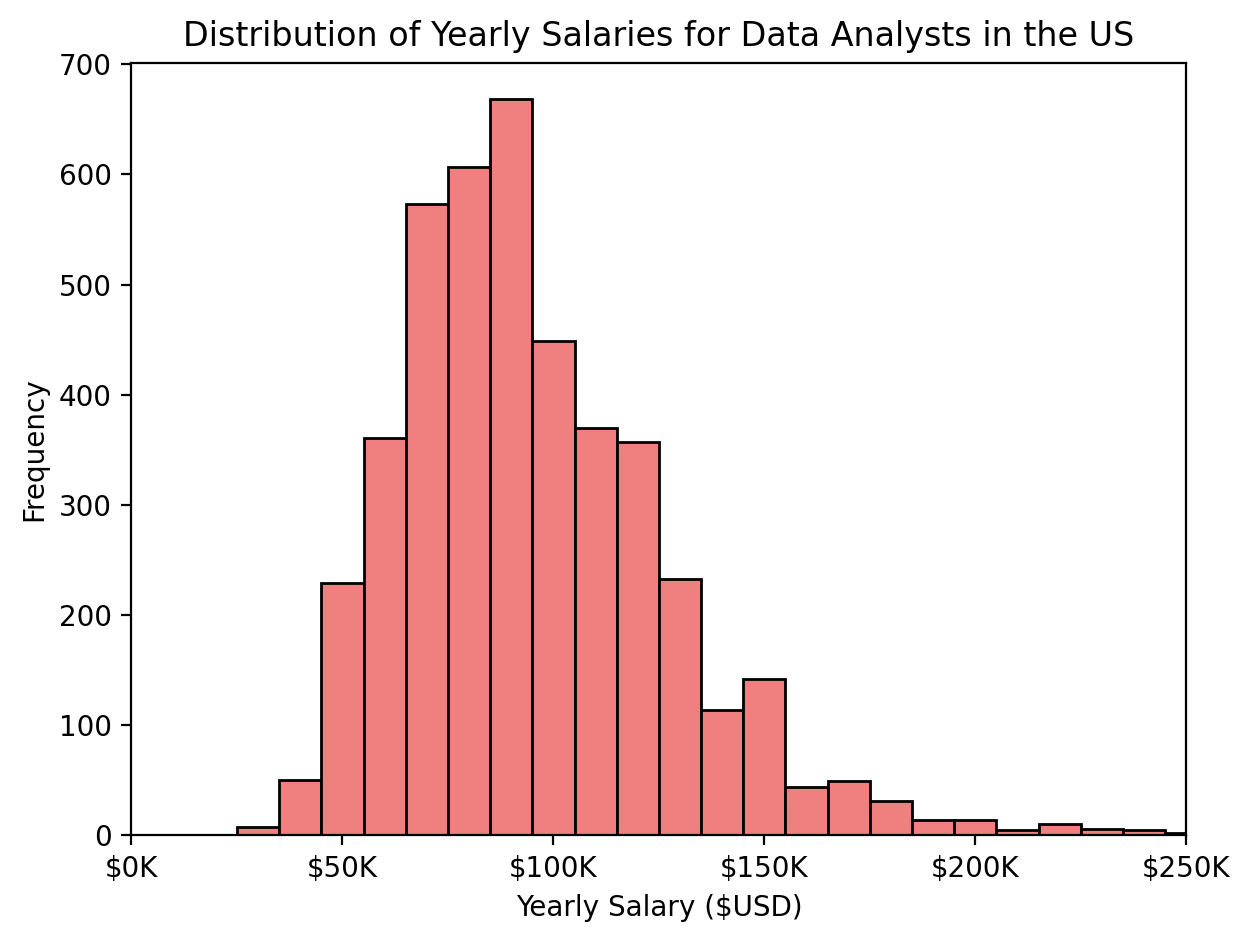

In [212]:

df_DA_US['salary_year_avg'].plot(
    kind='hist', 
    bins=35, 
    title="Distribution of Yearly Salaries for Data Analysts in the US", 
    color='lightcoral',
    edgecolor='black' # aggiunge un bordo nero alle barre per migliorare la leggibilità
)
plt.xlim(0, 250000) # limita l'asse x per concentrarsi sui salari più comuni
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel("Frequency")
plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US.dropna(subset=['salary_year_avg'], inplace=True) # rimuove le righe con valori NaN in salary_year_avg

# Matplotlib: Box Plot
Un box plot (o grafico a scatola) è un tipo di grafico che rappresenta la distribuzione di un insieme di dati attraverso cinque statistiche principali: il minimo, il primo quartile (Q1), la mediana (Q2), il terzo quartile (Q3) e il massimo. Il box plot è utile per identificare la presenza di outlier, la simmetria della distribuzione e la variabilità dei dati. Ecco come creare un box plot con Matplotlib:

In [ ]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df.dropna(subset=['salary_year_avg'], inplace=True) # rimuove le righe con valori NaN in salary_year_avg

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_country'] == 'United States') & (df['job_title_short'].isin(job_titles))].copy()

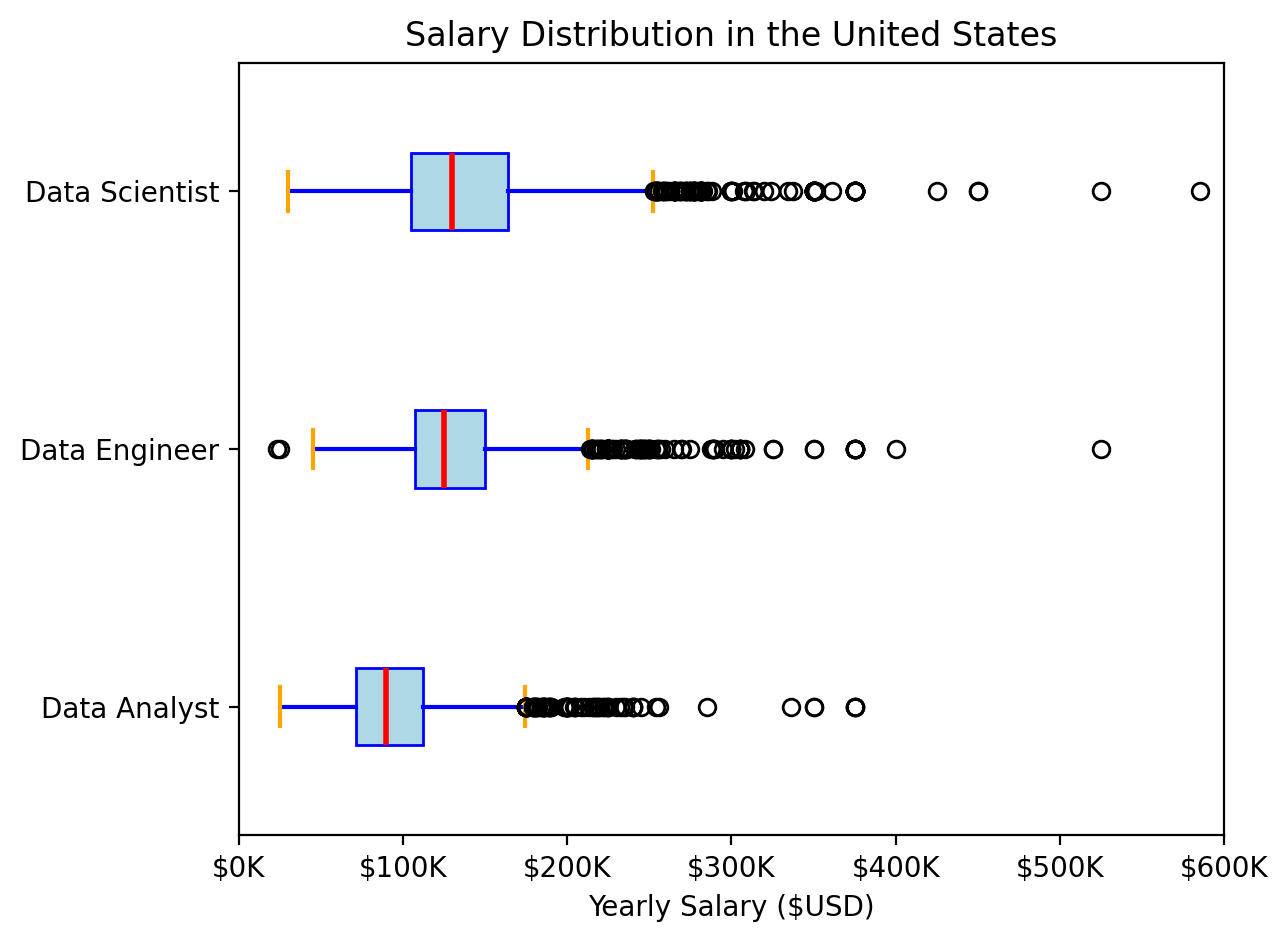

In [266]:
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, 
            tick_labels=job_titles, 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue', linewidth=1.5),
            capprops=dict(color='orange', linewidth=1.5)
)
plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.tight_layout()
plt.xlim(0, 600_000)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.show()

# Esercizio: Analisi dei pagamenti per skills
Analizziamo le 10 skills più pagate per Data Analyst e le 10 skills più richieste per Data Analyst. Creiamo due grafici a barre affiancati per visualizzare queste informazioni. Utilizziamo `barx` per creare i grafici e personalizziamo i colori e le etichette per rendere i grafici più chiari e informativi. 

In [269]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US.dropna(subset=['salary_year_avg'], inplace=True) # rimuove le righe con valori NaN in salary_year_avg
df_DA_US = df_DA_US.explode('job_skills')


In [274]:
df_DA_US_grouped = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_US_top_paid = df_DA_US_grouped.sort_values(by='median', ascending=False).head(10)
df_DA_US_top_skills = df_DA_US_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

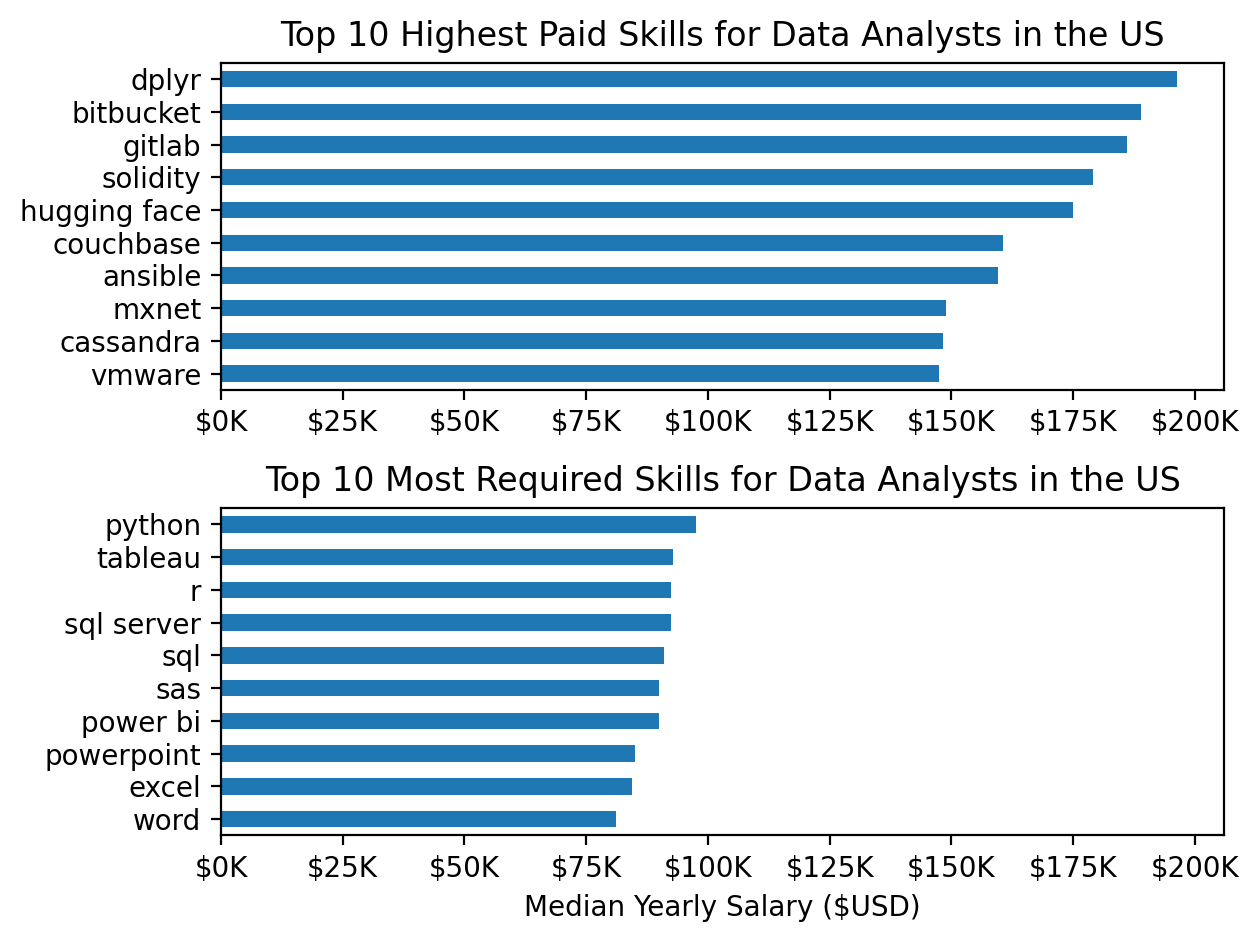

In [291]:
%config InlineBackend.figure_format = 'retina'
fig, axes = plt.subplots(2, 1)
df_DA_US_top_paid.plot(kind='barh', y='median', ax=axes[0], legend=False)
axes[0].invert_yaxis() # inverte l'asse y per avere la skill più pagata in alto
axes[0].set_title("Top 10 Highest Paid Skills for Data Analysts in the US")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari

df_DA_US_top_skills.plot(kind='barh', y='median', ax=axes[1], legend=False)
axes[1].invert_yaxis() # inverte l'asse y per avere la skill più richiesta in alto
axes[1].set_title("Top 10 Most Required Skills for Data Analysts in the US")
axes[1].set_ylabel("")
axes[1].set_xlabel("Median Yearly Salary ($USD)")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse x per mostrare i salari in migliaia di dollari
axes[1].set_xlim(axes[0].get_xlim()) # allinea l'asse x del secondo grafico a quello del primo
fig.tight_layout()
